# RBW Spectral Calibration

This notebook reloads the stored RBW calibration models under `models/spectral_calibration_rbw` and validates them on held-out RBW records.

**System boundary**
- Domain/core: RBW ranking, RBW-to-calibration adaptation, latent-variable fitting, deployment correction, and consensus fusion live in `measurement_calibration.*`.
- Application/orchestration: this notebook only reloads artifacts, recomputes lightweight summaries, and renders figures.
- Side effects: reading RBW acquisition/model files and rendering notebook output cells.

**Selection rule reused from `notebooks/sensor_ranking.ipynb`**
- `Node9` is excluded completely because it was deployed in Funza rather than Bogota.
- The reliable anchor sensor for each RBW is the best record-wise sensor that is not flagged as a PSD-distribution outlier on the retained Bogota subset.
- The remaining Bogota sensors are kept in the fit so the hold-out validation reflects network behavior rather than a hand-picked sensor pair.

In [1]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def power_linear_to_plot_db(
    power_linear: np.ndarray,
    floor_power: float = 1.0e-18,
) -> np.ndarray:
    """Convert linear power to dB with a plotting floor below the solver floor."""

    return 10.0 * np.log10(
        np.clip(np.asarray(power_linear, dtype=np.float64), floor_power, None)
    )


def build_artifact_summary_rows(
    artifacts: dict[str, object],
) -> list[dict[str, float | int | str]]:
    """Build table rows that summarize the stored RBW artifacts."""

    rows: list[dict[str, float | int | str]] = []
    for rbw_label in sorted(artifacts):
        manifest = artifacts[rbw_label].manifest
        extra_summary = manifest.get("extra_summary", {})
        result_summary = manifest["result_summary"]
        rows.append(
            {
                "rbw": rbw_label,
                "train_records": int(result_summary["train_experiments"]),
                "test_records": int(result_summary["test_experiments"]),
                "objective_start": float(result_summary["objective_start"]),
                "objective_end": float(result_summary["objective_end"]),
                "dispersion_ratio": float(
                    extra_summary["corrected_to_raw_dispersion_ratio"]
                ),
                "raw_mean_sensor_std_db": float(
                    extra_summary["raw_mean_sensor_std_db"]
                ),
                "corrected_mean_sensor_std_db": float(
                    extra_summary["corrected_mean_sensor_std_db"]
                ),
                "fit_duration_s": float(extra_summary["fit_duration_s"]),
            }
        )
    return rows


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import measurement_calibration.artifacts as artifacts_module  # noqa: E402
import measurement_calibration.rbw_calibration as rbw_calibration_module  # noqa: E402
import measurement_calibration.sensor_ranking as sensor_ranking_module  # noqa: E402
import measurement_calibration.spectral_calibration as spectral_calibration_module  # noqa: E402

artifacts_module = importlib.reload(artifacts_module)
rbw_calibration_module = importlib.reload(rbw_calibration_module)
sensor_ranking_module = importlib.reload(sensor_ranking_module)
spectral_calibration_module = importlib.reload(spectral_calibration_module)

load_spectral_calibration_artifact = artifacts_module.load_spectral_calibration_artifact
build_rbw_preparation_rows = rbw_calibration_module.build_rbw_preparation_rows
load_rbw_calibration_preparations = (
    rbw_calibration_module.load_rbw_calibration_preparations
)
build_distribution_summary_rows = sensor_ranking_module.build_distribution_summary_rows
build_sensor_ranking_rows = sensor_ranking_module.build_sensor_ranking_rows
apply_deployed_calibration = spectral_calibration_module.apply_deployed_calibration
compute_network_consensus = spectral_calibration_module.compute_network_consensus
power_linear_to_db = spectral_calibration_module.power_linear_to_db

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

RBW_DATA_ROOT = REPO_ROOT / "data" / "RBW_acquisitions"
ARTIFACT_ROOT = REPO_ROOT / "models" / "spectral_calibration_rbw"
SELECTED_RBW = "10K"
PLOT_STRIDE_TARGET = 1024
SELECTED_TEST_RECORD_INDEX = 0

In [2]:
preparations = load_rbw_calibration_preparations(RBW_DATA_ROOT)
artifacts = {
    rbw_label: load_spectral_calibration_artifact(ARTIFACT_ROOT / rbw_label)
    for rbw_label in sorted(preparations)
}

preparation_overview = pd.DataFrame(build_rbw_preparation_rows(preparations))
artifact_overview = pd.DataFrame(build_artifact_summary_rows(artifacts))
rbw_overview = (
    preparation_overview.merge(artifact_overview, on="rbw")
    .sort_values("rbw")
    .reset_index(drop=True)
)
display(rbw_overview)
print(f"Available RBW models: {', '.join(sorted(artifacts))}")

,rbw,sensor_ids,reliable_sensor_id,recordwise_winner_sensor_id,distribution_winner_sensor_id,distribution_outlier_sensor_ids,n_sensors,n_records,n_frequencies,recordwise_best_mean_correlation,distribution_best_similarity,train_records,test_records,objective_start,objective_end,dispersion_ratio,raw_mean_sensor_std_db,corrected_mean_sensor_std_db,fit_duration_s
0,100K,"Node1, Node3, Node4, Node5",Node1,Node4,Node5,Node4,4,29,512,0.9262,0.4345,23,6,-543768.6963,-606475.7872,0.4309,3.4110,1.4697,0.0815
1,10K,"Node1, Node3, Node4, Node5",Node3,Node3,Node5,Node4,4,60,4096,0.9229,0.4384,48,12,-10102163.2363,-10395176.2968,0.1977,3.2166,0.6359,0.5169
2,30K,"Node1, Node3, Node4, Node5",Node3,Node4,Node5,Node4,4,60,1024,0.9308,0.4366,48,12,-2477243.1895,-2561064.6707,0.2878,2.9417,0.8465,0.1759
3,3K,"Node1, Node3, Node4, Node5",Node3,Node3,Node1,Node4,4,60,16384,0.9064,0.6591,48,12,-42592603.3082,-43019439.6382,0.2216,1.5134,0.3354,2.5687


Available RBW models: 100K, 10K, 30K, 3K


In [3]:
selected_preparation = preparations[SELECTED_RBW]
selected_artifact = artifacts[SELECTED_RBW]
selected_dataset = selected_preparation.calibration_dataset
selected_result = selected_artifact.result

selected_ranking_table = (
    pd.DataFrame(build_sensor_ranking_rows(selected_preparation.ranking_result))
    .sort_values("rank")
    .reset_index(drop=True)
)
selected_distribution_table = (
    pd.DataFrame(
        build_distribution_summary_rows(selected_preparation.distribution_diagnostics)
    )
    .sort_values("rank")
    .reset_index(drop=True)
)

raw_test_power = selected_dataset.observations_power[:, selected_result.test_indices, :]
corrected_test_power = apply_deployed_calibration(
    observations_power=raw_test_power,
    gain_power=selected_result.gain_power,
    additive_noise_power=selected_result.additive_noise_power,
)
consensus_test_power = compute_network_consensus(
    corrected_power=corrected_test_power,
    residual_variance_power2=selected_result.residual_variance_power2,
)

raw_test_db = power_linear_to_db(raw_test_power)
corrected_test_db = power_linear_to_db(corrected_test_power)
consensus_test_db = power_linear_to_db(consensus_test_power)
raw_dispersion_db = np.std(raw_test_db, axis=0)
corrected_dispersion_db = np.std(corrected_test_db, axis=0)
corrected_residual_db = corrected_test_db - consensus_test_db[np.newaxis, :, :]
dispersion_ratio = float(np.mean(corrected_dispersion_db) / np.mean(raw_dispersion_db))

validation_metrics = pd.DataFrame(
    {
        "metric": [
            "train_records",
            "test_records",
            "mean_raw_sensor_std_db",
            "mean_corrected_sensor_std_db",
            "corrected_to_raw_dispersion_ratio",
            "sensor_low_information_fraction",
            "gain_cap_fraction",
            "noise_zero_fraction",
        ],
        "value": [
            int(selected_result.train_indices.size),
            int(selected_result.test_indices.size),
            float(np.mean(raw_dispersion_db)),
            float(np.mean(corrected_dispersion_db)),
            dispersion_ratio,
            float(np.mean(selected_result.low_information_mask)),
            float(np.mean(selected_result.gain_at_correction_bound_mask)),
            float(np.mean(selected_result.noise_zero_mask)),
        ],
    }
)
sensor_validation = pd.DataFrame(
    {
        "sensor_id": selected_result.sensor_ids,
        "mean_bias_to_consensus_db": np.mean(corrected_residual_db, axis=(1, 2)),
        "rmse_to_consensus_db": np.sqrt(np.mean(corrected_residual_db**2, axis=(1, 2))),
        "median_information_weight": np.median(
            selected_result.information_weight,
            axis=1,
        ),
        "low_information_fraction": np.mean(
            selected_result.low_information_mask,
            axis=1,
        ),
        "gain_cap_fraction": np.mean(
            selected_result.gain_at_correction_bound_mask,
            axis=1,
        ),
    }
).sort_values("rmse_to_consensus_db")

display(selected_ranking_table)
display(selected_distribution_table)
display(validation_metrics)
display(sensor_validation)
print(
    f"Selected RBW {SELECTED_RBW}: reliable anchor = {selected_preparation.reliable_sensor_id} | "
    f"excluded sensors = {', '.join(selected_preparation.excluded_sensor_ids)}"
)
print(
    "Distribution outliers among retained Bogota sensors: "
    + (
        ", ".join(selected_preparation.distribution_outlier_sensor_ids)
        if selected_preparation.distribution_outlier_sensor_ids
        else "none"
    )
)
print(
    "Hold-out validation summary: corrected dispersion is "
    f"{dispersion_ratio:.3f}x the raw dispersion."
)

,rank,sensor_id,mean_score,mean_correlation,score_std,mean_noise_floor_db,records
0,1,Node3,2.7687,0.9229,0.0082,-61.6048,60
1,2,Node4,2.7596,0.9199,0.0079,-66.0136,60
2,3,Node1,2.7549,0.9183,0.0075,-64.5036,60
3,4,Node5,2.6568,0.8856,0.0089,-59.5083,60


,rank,sensor_id,distribution_similarity,normalized_similarity,mean_psd_db,std_psd_db,min_psd_db,max_psd_db,value_count,is_low_similarity_outlier
0,1,Node5,1.3153,0.4384,-54.1479,10.6325,-65.2322,-13.4179,245760,False
1,2,Node1,1.1296,0.3765,-57.7785,9.7065,-67.8333,-19.7929,245760,False
2,3,Node3,0.9321,0.3107,-55.3664,9.6190,-64.7929,-16.6280,245760,False
3,4,Node4,0.3802,0.1267,-60.7441,8.0720,-68.9776,-24.6054,245760,True


,metric,value
0,train_records,48.0000
1,test_records,12.0000
2,mean_raw_sensor_std_db,3.2166
3,mean_corrected_sensor_std_db,0.6359
4,corrected_to_raw_dispersion_ratio,0.1977
5,sensor_low_information_fraction,0.8824
6,gain_cap_fraction,0.0039
7,noise_zero_fraction,0.0000


,sensor_id,mean_bias_to_consensus_db,rmse_to_consensus_db,median_information_weight,low_information_fraction,gain_cap_fraction
0,Node1,-0.0203,0.5734,0.0500,0.8794,0.0000
1,Node3,0.0336,0.7135,0.0500,0.8806,0.0000
2,Node4,-0.0913,0.8014,0.0500,0.8799,0.0100
3,Node5,0.5383,2.8609,0.0500,0.8899,0.0056


Selected RBW 10K: reliable anchor = Node3 | excluded sensors = Node9
Distribution outliers among retained Bogota sensors: Node4
Hold-out validation summary: corrected dispersion is 0.198x the raw dispersion.


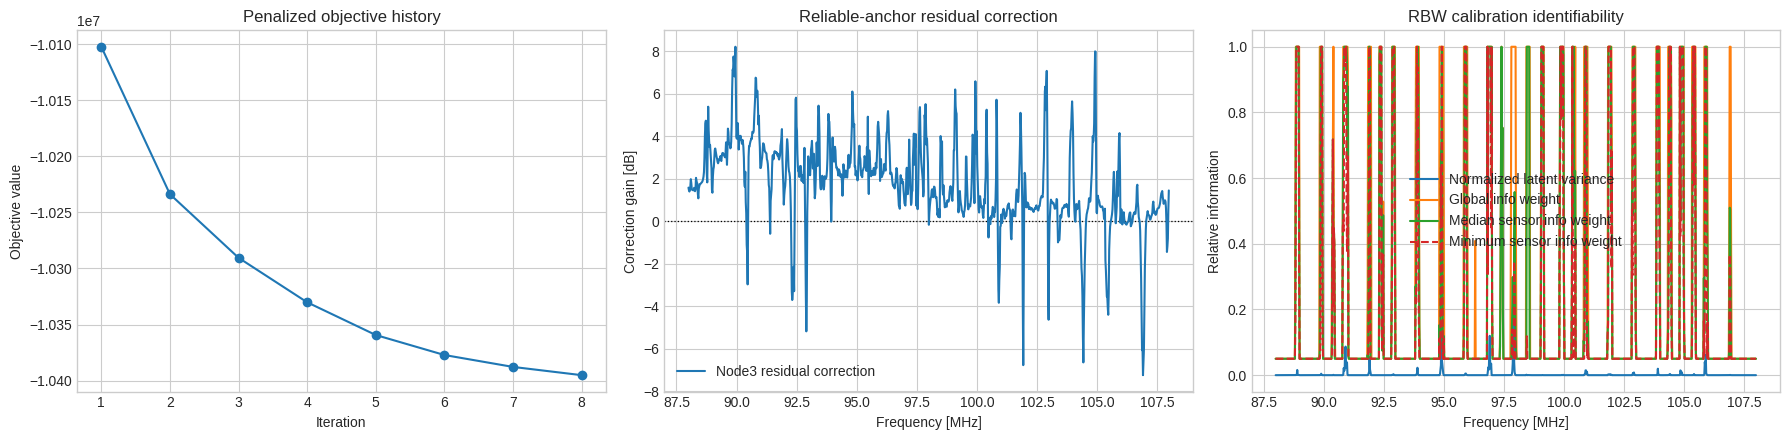

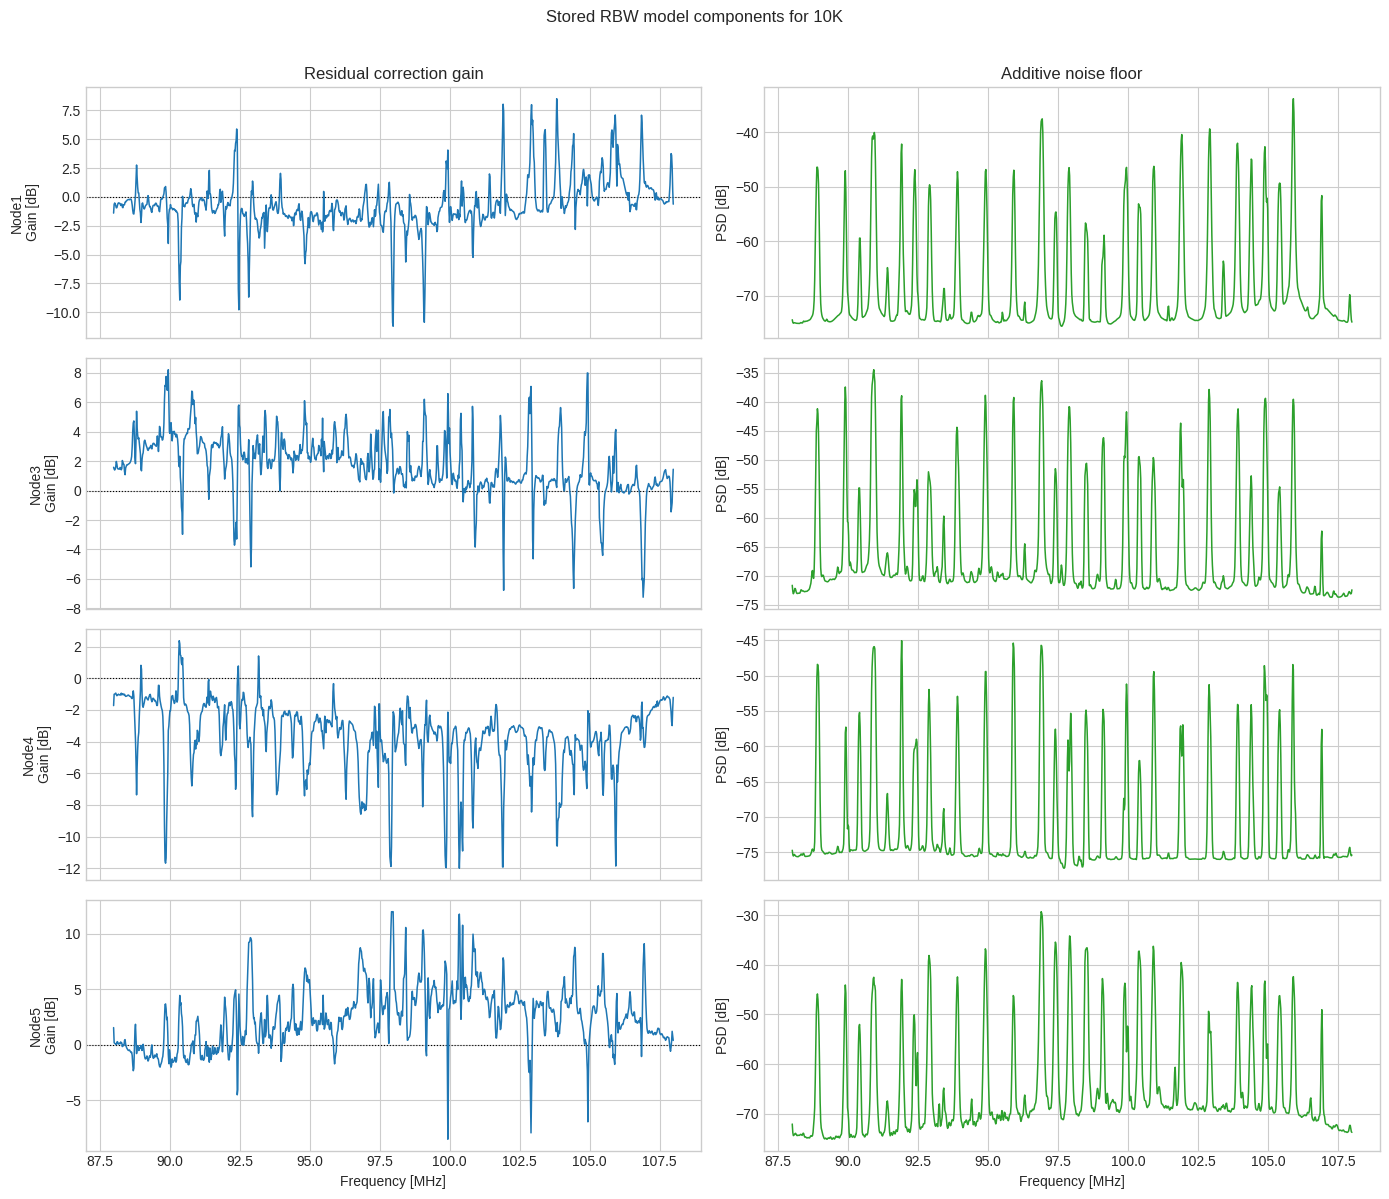

In [4]:
plot_stride = max(1, selected_result.frequency_hz.size // PLOT_STRIDE_TARGET)
freq_mhz = selected_result.frequency_hz[::plot_stride] / 1.0e6
anchor_index = selected_result.sensor_ids.index(selected_preparation.reliable_sensor_id)
normalized_latent_variation = selected_result.latent_variation_power2 / np.clip(
    np.max(selected_result.latent_variation_power2),
    1.0e-18,
    None,
)
median_sensor_information_weight = np.median(
    selected_result.information_weight,
    axis=0,
)
minimum_sensor_information_weight = np.min(
    selected_result.information_weight,
    axis=0,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(
    np.arange(1, selected_result.objective_history.size + 1),
    selected_result.objective_history,
    marker="o",
)
axes[0].set_title("Penalized objective history")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective value")

axes[1].axhline(0.0, color="black", linestyle=":", linewidth=0.9)
axes[1].plot(
    freq_mhz,
    power_linear_to_plot_db(
        selected_result.correction_gain_power[anchor_index, ::plot_stride]
    ),
    label=f"{selected_preparation.reliable_sensor_id} residual correction",
)
axes[1].set_title("Reliable-anchor residual correction")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Correction gain [dB]")
axes[1].legend()

axes[2].plot(
    freq_mhz,
    normalized_latent_variation[::plot_stride],
    label="Normalized latent variance",
)
axes[2].plot(
    freq_mhz,
    selected_result.frequency_information_weight[::plot_stride],
    label="Global info weight",
)
axes[2].plot(
    freq_mhz,
    median_sensor_information_weight[::plot_stride],
    label="Median sensor info weight",
)
axes[2].plot(
    freq_mhz,
    minimum_sensor_information_weight[::plot_stride],
    linestyle="--",
    label="Minimum sensor info weight",
)
axes[2].set_title("RBW calibration identifiability")
axes[2].set_xlabel("Frequency [MHz]")
axes[2].set_ylabel("Relative information")
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend()
plt.tight_layout()

correction_gain_db = power_linear_to_plot_db(
    selected_result.correction_gain_power[:, ::plot_stride]
)
noise_floor_db = power_linear_to_plot_db(
    selected_result.additive_noise_power[:, ::plot_stride]
)
n_sensors = len(selected_result.sensor_ids)

fig, axes = plt.subplots(
    n_sensors,
    2,
    figsize=(14, 3.0 * n_sensors),
    sharex=True,
    squeeze=False,
)
for row_index, sensor_id in enumerate(selected_result.sensor_ids):
    axes[row_index, 0].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
    axes[row_index, 0].plot(
        freq_mhz,
        correction_gain_db[row_index],
        linewidth=1.1,
    )
    axes[row_index, 0].set_ylabel(f"{sensor_id}\nGain [dB]")
    axes[row_index, 1].plot(
        freq_mhz,
        noise_floor_db[row_index],
        linewidth=1.1,
        color="tab:green",
    )
    axes[row_index, 1].set_ylabel("PSD [dB]")

axes[0, 0].set_title("Residual correction gain")
axes[0, 1].set_title("Additive noise floor")
for axis in axes[-1, :]:
    axis.set_xlabel("Frequency [MHz]")
fig.suptitle(f"Stored RBW model components for {SELECTED_RBW}", y=0.995)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.985))

Visualized hold-out record index: 0 of 11


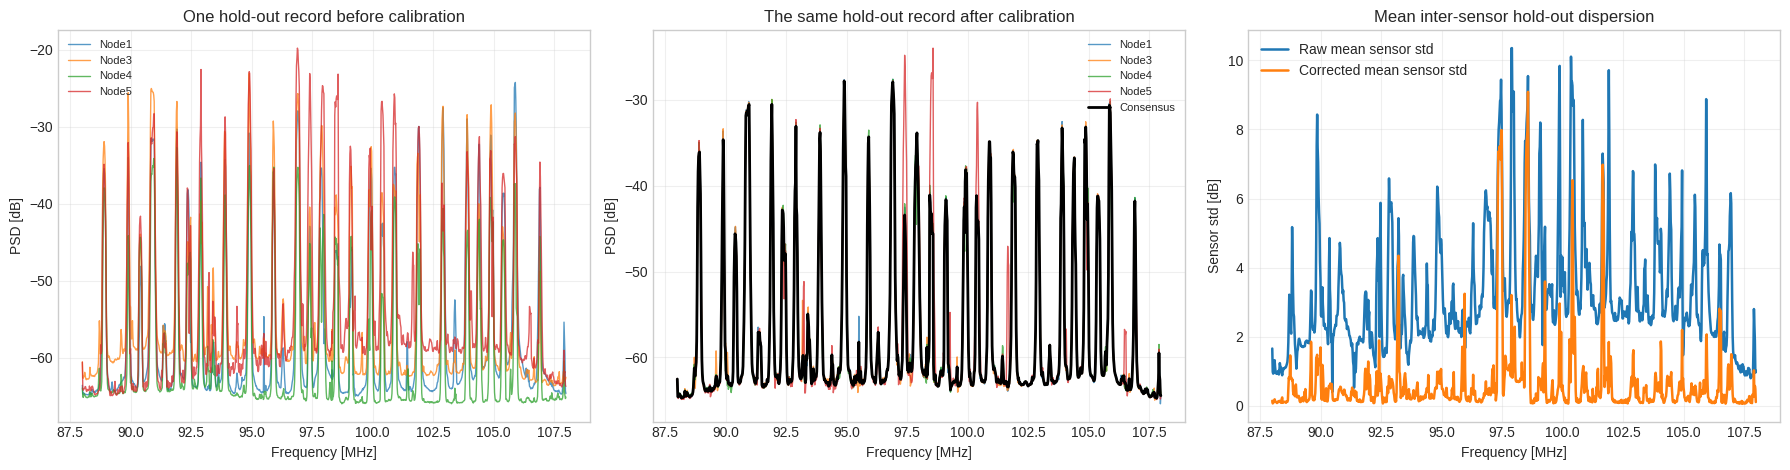

In [5]:
selected_test_record_index = min(
    SELECTED_TEST_RECORD_INDEX,
    raw_test_db.shape[1] - 1,
)
mean_raw_dispersion_freq_db = np.mean(raw_dispersion_db, axis=0)
mean_corrected_dispersion_freq_db = np.mean(corrected_dispersion_db, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for sensor_index, sensor_id in enumerate(selected_result.sensor_ids):
    axes[0].plot(
        freq_mhz,
        raw_test_db[sensor_index, selected_test_record_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.75,
        label=sensor_id,
    )
    axes[1].plot(
        freq_mhz,
        corrected_test_db[sensor_index, selected_test_record_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.75,
        label=sensor_id,
    )
axes[1].plot(
    freq_mhz,
    consensus_test_db[selected_test_record_index, ::plot_stride],
    color="black",
    linewidth=2.0,
    label="Consensus",
)
axes[0].set_title("One hold-out record before calibration")
axes[1].set_title("The same hold-out record after calibration")
for axis in axes[:2]:
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PSD [dB]")
    axis.grid(True, alpha=0.30)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)

axes[2].plot(
    freq_mhz,
    mean_raw_dispersion_freq_db[::plot_stride],
    linewidth=1.8,
    label="Raw mean sensor std",
)
axes[2].plot(
    freq_mhz,
    mean_corrected_dispersion_freq_db[::plot_stride],
    linewidth=1.8,
    label="Corrected mean sensor std",
)
axes[2].set_title("Mean inter-sensor hold-out dispersion")
axes[2].set_xlabel("Frequency [MHz]")
axes[2].set_ylabel("Sensor std [dB]")
axes[2].grid(True, alpha=0.30)
axes[2].legend()
plt.tight_layout()

print(
    f"Visualized hold-out record index: {selected_test_record_index} of {raw_test_db.shape[1] - 1}"
)